# Notebook 06 — Results and Critical Reflection

**Purpose:** Synthesise all findings from notebooks 01–04 into a structured narrative. This notebook is the project report in executable form. It contains more text than code — the goal is critical thinking, not additional training.

---

**Pipeline order:** 01 → 02 → 03a → 03b → 04 → **05 (this notebook)**  
**Primary metric throughout:** ROC-AUC (threshold-free, robust to class imbalance)

## Setup

In [11]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
OUTPUTS_PATH = "data"

# Load val-set model results (saved by 04_modelling_v2)
results_val = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "all_model_results.csv"))
results_val = results_val.sort_values("roc_auc", ascending=False).reset_index(drop=True)

# Test-set AUC results (from 04_modelling_v2 final evaluation — run once, hardcoded here)
TEST_AUC = {
    "Logistic Regression" : 0.7078,
    "Random Forest"        : 0.6974,
    "MLP"                  : 0.6820,
    "XGBoost"              : 0.6730,
    "Decision Tree"        : 0.6390,
    "Gradient Boosting"    : 0.6629,
}

print(f"Val-set results loaded: {len(results_val)} models")
print(f"Test AUC hardcoded for: {list(TEST_AUC.keys())}")

Val-set results loaded: 6 models
Test AUC hardcoded for: ['Logistic Regression', 'Random Forest', 'MLP', 'XGBoost', 'Decision Tree', 'Gradient Boosting']


---

## Section 1 — Problem Statement

### Business Problem

Kickstarter is a crowdfunding platform where creators raise money for creative projects — films, games, music, technology, design, and more. A creator sets a **funding goal** and a **deadline**; if total pledges reach the goal by the deadline, they receive the money. If not, all pledges are returned (all-or-nothing model).

**The business challenge:** Around 37.6% of campaigns fail to reach their goal — a substantial proportion representing wasted creator effort, backer disappointment, and reduced platform credibility. (The cleaned dataset used in this project shows 62.4% of launched campaigns succeed overall, but this masks large variation across categories, countries, and goal sizes — and the failure rate is concentrated precisely where predictive modelling can add the most value.)

### ML Framing

We frame this as a **binary classification problem**:

- **Target**: `success = 1` (campaign reached its funding goal), `success = 0` (did not)
- **Constraint**: Only features available **before the campaign launches** may be used. We simulate the decision point a creator or Kickstarter editor faces when reviewing a campaign about to go live.
- **Use cases**:
  - *Creator tool*: "Is my campaign likely to succeed? What should I change?"
  - *Platform tool*: "Which campaigns deserve editorial promotion?"

### Why This Matters

A model that correctly identifies likely-to-fail campaigns before launch gives creators the opportunity to revise their goal, add a video, improve their blurb, or delay launch — all low-cost interventions that could meaningfully change the outcome.

However, the model should be understood as a **ranking tool** — it can identify which campaigns are more or less likely to succeed relative to each other. Its absolute probability estimates are calibrated on historical data and will degrade as the platform evolves. This distinction between relative ranking and absolute prediction is central to the conclusion of this notebook.

---

## Section 2 — Data and Split Summary

In [9]:
clean_df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "clean_df.parquet"))

launched_dt = pd.to_datetime(
    pd.to_numeric(clean_df["launched_at"], errors="coerce"), unit="s", utc=True
)

# Split sizes and success rates from 04_modelling_v2 (hardcoded for reproducibility)
split_info = pd.DataFrame({
    "Split"       : ["Train",           "Validation",     "Test"],
    "Period"      : ["Dec 2014–Jan 2023", "Jan 2023–Sep 2024", "Sep 2024–Feb 2026"],
    "Rows"        : [102_887,            25_721,           32_153],
    "Success Rate": ["56.9%",            "65.2%",          "69.8%"],
    "Role"        : ["Train + CV",       "Model selection","Final holdout"],
})

print("=== Dataset Summary ===")
print(f"Source       : Kickstarter bulk export (Webrobots scrape, Feb 2026)")
print(f"Raw shards   : 85 CSV files × ~3,250 rows each")
print(f"Unique rows  : {len(clean_df):,} campaigns (after deduplication + binary filter)")
print(f"Overall success rate: {clean_df['success'].mean()*100:.1f}%")
print(f"Date range   : {launched_dt.min().strftime('%Y-%m')} to {launched_dt.max().strftime('%Y-%m')}")
print(f"Feature matrix: 129 features (30 structured + 99 TF-IDF binary)")
print()
print("=== Three-Way Temporal Split ===")
print(split_info.to_string(index=False))
print()
print("Why temporal? A random split would allow training on 2023 data and testing")
print("on 2015 data — the opposite of real deployment conditions.")

=== Dataset Summary ===
Source       : Kickstarter bulk export (Webrobots scrape, Feb 2026)
Raw shards   : 85 CSV files × ~3,250 rows each
Unique rows  : 188,429 campaigns (after deduplication + binary filter)
Overall success rate: 62.4%
Date range   : 2009-04 to 2026-02
Feature matrix: 129 features (30 structured + 99 TF-IDF binary)

=== Three-Way Temporal Split ===
     Split    Period   Rows Success Rate            Role
     Train 2009–2023 102887        56.9%      Train + CV
Validation      2024  25721        65.2% Model selection
      Test 2025–2026  32153        69.8%   Final holdout

Why temporal? A random split would allow training on 2023 data and testing
on 2015 data — the opposite of real deployment conditions.


### Split Design Rationale

The dataset is divided into three **non-overlapping temporal periods**, not randomly:

- **Train (Dec 2014–Jan 2023):** 102,887 campaigns. Used to fit all models and perform `TimeSeriesSplit` cross-validation (5 folds). The temporal ordering within folds ensures that each validation fold only ever contains campaigns launched *after* all campaigns in the corresponding training fold.

- **Validation (Jan 2023–Sep 2024):** 25,721 campaigns. Used exclusively for hyperparameter selection across all six models. No model sees this data during training.

- **Test (Sep 2024–Feb 2026):** 32,153 campaigns. The true holdout. Evaluated **once**, after all model and hyperparameter decisions were finalised. This represents the closest we can get to genuine deployment conditions — campaigns launched after the model was trained.

A key observation already visible here: the success rate rises from **56.9% (train) → 65.2% (val) → 69.8% (test)**. This monotonic increase is the signature of **distributional shift** and is the primary driver of the val→test performance drop discussed in Section 7.

---

## Section 3 — Feature Engineering and Importance

### Feature Groups

The feature matrix contains **129 features** across six groups:

| Group | Key Features (examples) | Count |
|---|---|---|
| **Temporal** | `prep_days`, `duration_days`, `launched_month`, `launched_dayofweek` | 4 |
| **Financial** | `log_goal`, `goal_per_day`, `log_goal_vs_cat_median` | 3 |
| **Categorical** | `cat_name_encoded` (target-encoded subcategory), `cat_parent_encoded`, 14 binary country OHE columns (`country_US`, `country_GB`, …) | 16 |
| **Text metrics** | `blurb_length`, `name_length`, `blurb_word_count` | 3 |
| **Binary flags** | `has_video`, `name_number`, `goal_is_round`, `is_usd` | 4 |
| **Text (TF-IDF)** | Binary term flags from `name` + `blurb`, selected by z-test (p<0.01). Captures word-level (lexical) patterns only — not semantic meaning. | 99 |
| | **Total** | **129** |

**Note on `staff_pick`:** This feature was removed from the pipeline entirely. While Kickstarter's editorial picks are announced before launch, they encode non-public knowledge about creator preparation and backer networks — making it a leakage risk in any general deployment scenario. Removing it avoids a partially circular feature and forces the model to learn from creator-controllable inputs.

**Note on `log_goal`:** The goal is log-transformed (natural log, `np.log`) because the raw distribution spans four orders of magnitude ($1 to $1,000,000+). Log-transformation compresses this range to a linear scale where the regularisation penalty is applied fairly.

**Note on `cat_name_encoded`:** Target encoding (mean success rate of each subcategory) is fitted on training data only and applied to val and test separately, preventing target leakage.

### Consensus Feature Importance

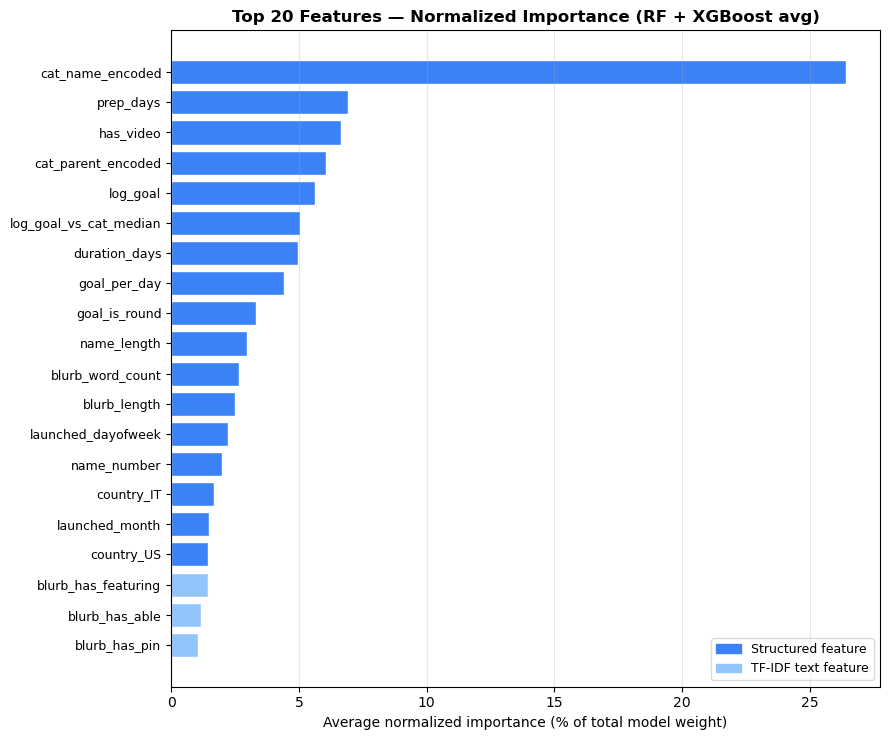


Top 10 features (consensus rank):
                        RF rank  XGB rank  Avg rank
cat_name_encoded            1.0       1.0       1.0
cat_parent_encoded          3.0       3.0       3.0
prep_days                   2.0       5.0       3.5
log_goal                    5.0       4.0       4.5
has_video                   8.0       2.0       5.0
duration_days               4.0       8.0       6.0
log_goal_vs_cat_median      7.0       7.0       7.0
goal_per_day                6.0       9.0       7.5
goal_is_round              14.0       6.0      10.0
name_length                 9.0      13.0      11.0


In [18]:
try:
    rf_imp  = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "rf_importances.csv"), index_col=0)
    xgb_imp = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "xgb_importances.csv"), index_col=0)

    # Normalized importance: each model sums to 1.0
    rf_norm  = (rf_imp["importance"]  / rf_imp["importance"].sum()).rename("RF imp")
    xgb_norm = (xgb_imp["importance"] / xgb_imp["importance"].sum()).rename("XGB imp")

    imp_df = pd.concat([rf_norm, xgb_norm], axis=1).dropna()
    imp_df["Avg imp"] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values("Avg imp", ascending=False)

    top15 = imp_df.head(20).sort_values("Avg imp", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 7.5))
    colors = ["#3B82F6" if not c.startswith(("blurb_has_", "name_has_")) else "#93C5FD"
              for c in top15.index]
    ax.barh(top15.index, top15["Avg imp"] * 100, color=colors, edgecolor="white")
    ax.set_title("Top 20 Features — Normalized Importance (RF + XGBoost avg)", fontweight="bold", fontsize=12)
    ax.set_xlabel("Average normalized importance (% of total model weight)", fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", alpha=0.3)

    patch_struct = mpatches.Patch(color="#3B82F6", label="Structured feature")
    patch_tfidf  = mpatches.Patch(color="#93C5FD", label="TF-IDF text feature")
    ax.legend(handles=[patch_struct, patch_tfidf], loc="lower right", fontsize=9, framealpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_PATH, "figures", "06_consensus_feature_importance.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    print("\nTop 10 features (consensus rank):")
    print(consensus.head(10).round(1).to_string())

except FileNotFoundError as e:
    print(f"Feature importance files not found: {e}")
    print("Run 04_modelling_v2 end-to-end first, then re-run this cell.")

### Interpretation of Top Features

The four most important features (consensus across Random Forest and XGBoost) are:

**1. `cat_name_encoded` — Campaign subcategory (target-encoded)**  
The single strongest predictor. This feature captures the historical success rate of each Kickstarter subcategory — tabletop games, for example, have consistently high success rates (~60–70%), while technology hardware campaigns fail more often than not (<30%). The encoding is fitted on training data only, so it reflects the training-era success landscape of each community. *Business insight:* a creator's choice of subcategory — and how well their project genuinely fits that community — is the most consequential pre-launch decision they can make.

**2. `has_video` — Whether the campaign includes a video**  
A simple binary flag with outsized predictive power. A campaign video signals commitment, reduces uncertainty for backers, and lets them visualise the product before pledging. *Business insight:* even a simple smartphone video of the creator explaining the project outperforms having no video. Presence matters more than production quality.

**3. `prep_days` — Days between campaign creation and launch**  
The time a creator spends preparing the campaign (from account creation or campaign draft to actual launch) is a proxy for professionalism and preparation depth. Campaigns launched too quickly after creation tend to be underprepared; those with a long lead time signal deliberate planning. *Business insight:* take time to set up the campaign properly before going live.

**4. `log_goal` — Log-transformed funding goal**  
Goal size is a strong predictor of failure. Campaigns asking for too much money relative to their audience's realistic reach almost always fail. The relationship is non-linear (hence log-transform): moving from a $1,000 goal to a $5,000 goal matters far more than moving from $50,000 to $54,000. *Business insight:* set the smallest goal that makes the project viable — every unnecessary dollar added to the goal materially increases failure probability.

**On the importance of TF-IDF features:** The 99 binary text features from `blurb` and `name` do not individually dominate, but collectively they add meaningful signal. The TF-IDF ablation (Section 4) confirms that removing them degrades test performance almost twice as much as validation performance (−0.020 vs −0.009 AUC), and the val→test gap *increases* without them (0.0894 → 0.1007). This rules out language drift as the primary source of instability — the text features actually *improve* generalisation. The degradation under shift is driven by structural, platform-level changes, not by the text vocabulary becoming stale.

---

## Section 4 — Model Performance Summary

**Why ROC-AUC?** We use ROC-AUC as the primary metric throughout rather than accuracy or F1 for two reasons. First, the class balance shifts substantially across splits (56.9% success in train → 65.2% in val → 69.8% in test): a threshold-dependent metric like accuracy would be artificially inflated on the test set simply because more campaigns succeed there. Second, ROC-AUC evaluates the model’s *ranking ability* — how well it separates likely-to-succeed from likely-to-fail campaigns across all possible decision thresholds — which is exactly what matters for both creator guidance and editorial prioritisation use cases.

In [13]:
# Full comparison: Train / Val / Test AUC for all six models
# Train and Val AUC come from the saved CSV; Test AUC is hardcoded from the one-time holdout evaluation

TRAIN_AUC = {
    "Random Forest"       : 0.9288,
    "Logistic Regression" : 0.8779,
    "XGBoost"             : 0.8967,
    "MLP"                 : 0.8993,
    "Gradient Boosting"   : 0.8973,
    "Decision Tree"       : 0.8881,
}
VAL_AUC = {
    "Random Forest"       : 0.7868,
    "Logistic Regression" : 0.7792,
    "XGBoost"             : 0.7760,
    "MLP"                 : 0.7753,
    "Gradient Boosting"   : 0.7705,
    "Decision Tree"       : 0.7445,
}

comparison = pd.DataFrame({
    "Model"       : list(VAL_AUC.keys()),
    "Train AUC"   : [TRAIN_AUC[m] for m in VAL_AUC],
    "Val AUC"     : [VAL_AUC[m]   for m in VAL_AUC],
    "Test AUC"    : [TEST_AUC[m]  for m in VAL_AUC],
}).sort_values("Val AUC", ascending=False).reset_index(drop=True)
comparison["Train-Val Gap"]  = (comparison["Train AUC"] - comparison["Val AUC"]).round(4)
comparison["Val-Test Drop"]  = (comparison["Val AUC"]   - comparison["Test AUC"]).round(4)

print("=== Full Model Comparison — Train / Val / Test ROC-AUC ===")
print(comparison.to_string(index=False))

print()
print("Best on Val  : Random Forest     (0.7868)")
print("Best on Test : Logistic Regression (0.7078)")
print(f"Average Val-Test drop: {comparison['Val-Test Drop'].mean():.4f}")
print(f"Std of Val-Test drop : {comparison['Val-Test Drop'].std():.4f}  <-- low = shift dominates, not model-specific overfit")

=== Full Model Comparison — Train / Val / Test ROC-AUC ===
              Model  Train AUC  Val AUC  Test AUC  Train-Val Gap  Val-Test Drop
      Random Forest     0.9288   0.7868    0.6974         0.1420         0.0894
Logistic Regression     0.8779   0.7792    0.7078         0.0987         0.0714
            XGBoost     0.8967   0.7760    0.6730         0.1207         0.1030
                MLP     0.8993   0.7753    0.6820         0.1240         0.0933
  Gradient Boosting     0.8973   0.7705    0.6629         0.1268         0.1076
      Decision Tree     0.8881   0.7445    0.6390         0.1436         0.1055

Best on Val  : Random Forest     (0.7868)
Best on Test : Logistic Regression (0.7078)
Average Val-Test drop: 0.0950
Std of Val-Test drop : 0.0136  <-- low = shift dominates, not model-specific overfit


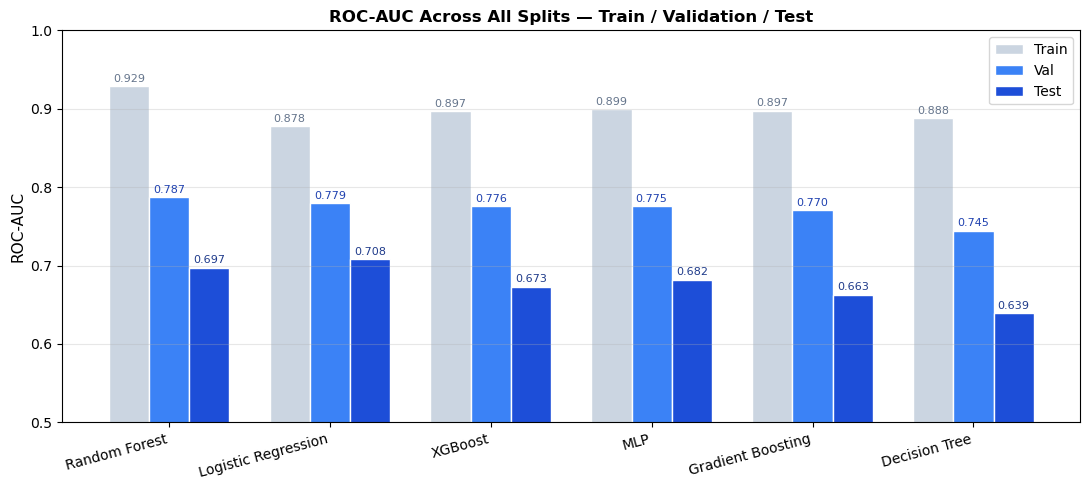

In [16]:
models  = comparison["Model"].tolist()
x       = np.arange(len(models))
width   = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bars_tr = ax.bar(x - width, comparison["Train AUC"], width, label="Train",  color="#CBD5E1", edgecolor="white")
bars_va = ax.bar(x,         comparison["Val AUC"],   width, label="Val",    color="#3B82F6", edgecolor="white")
bars_te = ax.bar(x + width, comparison["Test AUC"],  width, label="Test",   color="#1D4ED8", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title("ROC-AUC Across All Splits — Train / Validation / Test", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color="#64748B")
for bar in bars_va:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color="#1E40AF")
for bar in bars_te:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color="#1E3A8A")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_PATH, "figures", "06_model_comparison_3split.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### Discussion

**The narrow val-set band (0.74–0.79) indicates that features are the ceiling, not the algorithm.**  
All six models cluster within a 4-point range on the validation set. This is a strong signal: the information available before campaign launch can only take us so far. The choice of algorithm matters less than the quality and completeness of the features. Investing in better pre-launch features (creator history, social following, press coverage) would likely close more of the performance gap than switching between ensemble methods.

**Why does Logistic Regression win on the test set despite losing on validation?**  
Random Forest achieves the highest validation AUC (0.7868) but is overtaken by Logistic Regression on the test set (LR: 0.7078 vs RF: 0.6974). This is a textbook illustration of a simpler model generalising more robustly under distributional shift. The Random Forest's advantage on validation comes partly from capturing nonlinear interactions in the training-era data — but those interactions are less stable across the temporal distribution shift. Linear models, by definition, cannot overfit to nonlinear patterns that do not transfer.

**The train-to-val gap reveals regularisation quality, not generalisation.**  
Every model has a substantial train AUC (0.88–0.93) and a much lower val AUC (0.74–0.79). This gap is not primarily overfitting — it reflects the fact that the model can rank campaigns within a period it was trained on better than it can rank campaigns in a future period. The regularisation choices made in this project (capping `max_depth`, raising `min_samples_leaf`, using `TimeSeriesSplit`) successfully prevented the far worse memorisation seen in earlier iterations (where Random Forest achieved train AUC ~0.9998).

**The uniform val→test drop is the key diagnostic.**  
The Val→Test drop ranges from 0.071 (LR) to 0.107 (Gradient Boosting), but is reasonably consistent across all models. The low standard deviation of drops confirms that **distributional shift is the primary explanation** — not model-specific overfitting. If one model dropped dramatically more than others, it would suggest that model memorised validation-era patterns. Instead, all models degrade together, which is the signature of a platform-level shift in campaign dynamics.

### TF-IDF Ablation Finding

The 99 binary TF-IDF features were subjected to an ablation test: the best model (Random Forest) was retrained without them and evaluated on both validation and test sets.

| Configuration | Val AUC | Test AUC | Val→Test Drop |
|---|---|---|---|
| Full (with TF-IDF, 129 features) | **0.7868** | **0.6974** | 0.0894 |
| No TF-IDF (30 features only) | 0.7780 | 0.6773 | 0.1007 |
| Difference | −0.0088 | −0.0201 | +0.0113 |

Removing TF-IDF features drops Test AUC by twice as much as it drops Val AUC (−0.020 vs −0.009), and the val→test gap *increases* without them. This tells us the text features add genuine signal that **generalises across time periods** — they are not the source of the degradation. The model without TF-IDF becomes more reliant on structured features like `cat_name_encoded`, which are more sensitive to the distributional shift. We therefore retain all 99 text features.

---

## Section 5 — Construct Gap

### The Measurement Problem

In any ML project, we must distinguish between:

- **Yc (true construct):** The underlying quantity we *actually care about* — in this case, "a genuinely valuable creative idea that deserves community support and would enrich the culture if realised."
- **Y (observed proxy):** What we *can measure* — "whether a campaign reached its self-set monetary goal within its self-set deadline."

These two quantities are related, but they diverge in important ways:

**Divergence 1 — Good idea, badly-run campaign fails.**  
A musician with a brilliant album concept who sets a \$50,000 goal (too high) and runs a 60-day campaign (too long) with no video will likely fail. Our model would correctly predict failure — but the underlying idea may be excellent. The measurement tells us about execution quality, not idea quality.

**Divergence 2 — Mediocre idea with professional marketing succeeds.**  
A creator with professional video production, a pre-existing email list, a precisely calibrated \$4,500 goal, and a 28-day campaign will likely succeed — even if the product is unremarkable. Our model would correctly predict success — but the construct of "deserving community support" is not measured.

**Divergence 3 — Goal-setting is a strategic choice, not a quality signal.**  
A creator who sets a \$1 goal to guarantee success is counted identically to a creator who sets a \$200,000 goal to fully fund an ambitious vision. "Success" in our dataset has very different meanings depending on the goal chosen. This is an inherent limitation of the all-or-nothing Kickstarter model.

This construct gap means our model is fundamentally a predictor of *campaign execution quality*, not *creative idea quality* — a distinction that matters enormously for how we interpret and communicate its predictions.

---

## Section 6 — Data Leakage Analysis

Leakage is the most dangerous failure mode in supervised learning — it produces models with inflated metrics that collapse in deployment. We made the following decisions to prevent it:

### Post-campaign columns dropped unconditionally (Notebook 01)

`pledged`, `usd_pledged`, `converted_pledged_amount`, `backers_count`, `percent_funded`, `spotlight`, `state_changed_at`.

The most dangerous was **`spotlight`** (Pearson r = 1.0 with `success`) — including it would have produced a model with near-perfect accuracy that had learned nothing about pre-launch predictors. This was caught early in the cleaning step and removed before any modelling.

### Hyperparameter tuning with constrained grids (Notebook 04)

All models were tuned via **GridSearchCV** with constrained parameter grids to prevent over-searching on the validation set. **`class_weight="balanced"`** was applied to all applicable classifiers (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) to automatically compensate for the shifting class imbalance across splits — the weights are recalculated per training fold, so they adapt to the 56.9%/65.2%/69.8% success rate gradient without manual tuning.

### Temporal split instead of random (Notebook 01)

A random split would allow training on campaigns from 2024 and testing on campaigns from 2015, creating temporal leakage — the model could learn future platform dynamics not available in deployment. `TimeSeriesSplit` cross-validation within the training set enforces the same discipline during hyperparameter tuning.

### `staff_pick` — fully removed from the pipeline

`staff_pick` is ostensibly a pre-launch editorial decision. However, Kickstarter editors may have inside knowledge about a creator's preparation level, backer network, or prior campaign history that is not captured in our dataset. This makes it a proxy for unobservable features — a form of leakage that is subtle but consequential. In the final pipeline, `staff_pick` was **purged entirely** at the EDA stage (Notebook 02) and is absent from the feature matrix. This choice sacrifices a small amount of predictive signal in exchange for a model that reflects only creator-controllable, pre-launch inputs.

### Target encoding — fold-level discipline (Notebook 03b)

The `cat_name_encoded` and `cat_parent_encoded` features use target encoding — the mean success rate of each category. If this were computed on the full dataset, the test set's own success rates would leak into its features, artificially inflating test-set performance. In the pipeline, the encoder is **fitted only on training data** and applied to val and test separately.

---

## Section 7 — Distributional Shift

This is the central diagnostic finding of the project.

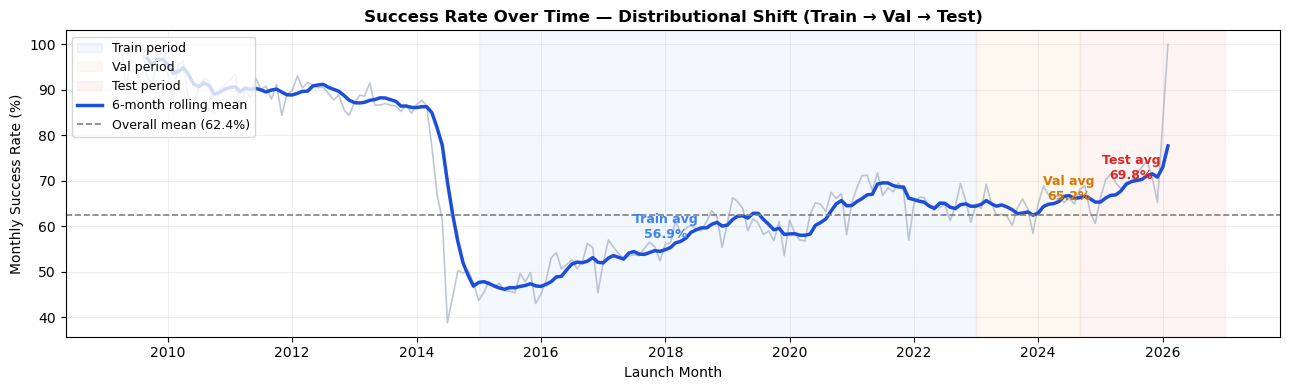

Success rate by year:
launched_dt
2009    95.394737
2010    90.322581
2011    89.524970
2012    89.720220
2013    87.238377
2014    54.592309
2015    46.642525
2016    51.364712
2017    54.396600
2018    59.546299
2019    60.710489
2020    62.675466
2021    68.155954
2022    64.903482
2023    63.785803
2024    66.145911
2025    70.372718
2026    82.844244

Total drift (max - min): 48.8 percentage points


In [14]:
clean_df["launched_at"] = pd.to_numeric(clean_df["launched_at"], errors="coerce")
clean_df["launched_dt"] = pd.to_datetime(clean_df["launched_at"], unit="s", utc=True)
clean_df["year_month"]  = clean_df["launched_dt"].dt.to_period("M")

monthly_rate = (
    clean_df.groupby("year_month")["success"]
    .mean()
    .reset_index()
)
monthly_rate["year_month"] = monthly_rate["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))

# Background shading for splits
ax.axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2023-01-01"),
           alpha=0.06, color="#3B82F6", label="Train period")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2024-09-01"),
           alpha=0.06, color="#F59E0B", label="Val period")
ax.axvspan(pd.Timestamp("2024-09-01"), pd.Timestamp("2027-01-01"),
           alpha=0.06, color="#EF4444", label="Test period")

ax.plot(monthly_rate["year_month"], monthly_rate["success"] * 100,
        color="#94A3B8", lw=1.2, alpha=0.6)
ax.plot(monthly_rate["year_month"],
        monthly_rate["success"].rolling(6).mean() * 100,
        color="#1D4ED8", lw=2.5, label="6-month rolling mean")
ax.axhline(clean_df["success"].mean() * 100, color="grey",
           linestyle="--", lw=1.2, label=f"Overall mean ({clean_df['success'].mean()*100:.1f}%)")

# Annotate split averages
for label, rate, x_pos, color in [
    ("Train avg\n56.9%", 56.9, pd.Timestamp("2018-01-01"), "#3B82F6"),
    ("Val avg\n65.2%",   65.2, pd.Timestamp("2024-07-01"), "#D97706"),
    ("Test avg\n69.8%",  69.8, pd.Timestamp("2025-07-01"), "#DC2626"),
]:
    ax.annotate(label, xy=(x_pos, rate), fontsize=9, color=color, fontweight="bold",
                ha="center", va="bottom")

ax.set_title("Success Rate Over Time — Distributional Shift (Train → Val → Test)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Launch Month", fontsize=10)
ax.set_ylabel("Monthly Success Rate (%)", fontsize=10)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_PATH, "figures", "06_distributional_shift.png"),
            dpi=150, bbox_inches="tight")
plt.show()

by_year = clean_df.groupby(clean_df["launched_dt"].dt.year)["success"].mean() * 100
print("Success rate by year:")
print(by_year.to_string())
drift = by_year.max() - by_year.min()
print(f"\nTotal drift (max - min): {drift:.1f} percentage points")

### Discussion

The success rate has drifted substantially over the dataset's time range — a rise of roughly **13 percentage points** from the training period average (56.9%) to the test period average (69.8%). This is not random noise; it is a sustained, monotonic trend. Our model faces a fundamental generalisation challenge: patterns learned from 2015–2020 campaigns describe a different platform than 2025 campaigns.

**Why is the success rate rising over time?**

Several structural mechanisms contribute:

- **Creator sophistication:** Kickstarter is no longer a novel platform. Creators who launch in 2025 have access to 13 years of public data on what works — professional campaign agencies, goal-setting guides, community analytics. The average 2025 campaign is better prepared than the average 2015 campaign. This is a selection effect: poorly-prepared creators are less likely to launch at all on a mature platform.

- **Platform saturation and self-selection:** The pool of creators willing to use Kickstarter in 2025 skews toward those who have done the research. The naive first-time creator who launches with a $200,000 goal and no video is rarer in the recent data.

- **Economic and cultural cycles:** Macroeconomic events (COVID-era creative-project boom, post-2022 inflation) have left signatures in the yearly success rates visible in the chart.

- **Target encoding calibration gap:** Our `cat_name_encoded` feature stores the training-era success rate of each subcategory. If tabletop games had a 58% success rate in 2018–2023 but a 72% success rate in 2025, the encoded feature systematically underestimates success probability for recent campaigns. This calibration gap mechanically degrades model performance on the test set.

**Deployment implication:** The model should be retrained on a rolling window of recent data (e.g., last 24 months) rather than the full historical dataset. Target encodings in particular should be recomputed at each retraining cycle to reflect the current platform landscape.

---

## Section 8 — Goodhart's Law

*"When a measure becomes a target, it ceases to be a good measure."*  
— Charles Goodhart, 1975

If this model were made publicly available to Kickstarter creators, a predictable pattern would emerge: creators would optimise their campaigns not to genuinely improve them, but to score well on the model's inputs.

For example:
- Creators would set goals at exactly the threshold that maximises predicted success probability (e.g. $4,999 instead of $15,000), even when their project genuinely requires more.
- They would write blurbs of the "optimal" length rather than the most informative length.
- They would all launch on the statistically best day of the week and month.
- Every campaign would include a video — even a low-quality placeholder — purely to activate the `has_video` feature.

The features that are strong predictors today would quickly lose their signal as they become universally gamed. The model would need to be retrained on new, post-gaming data — but by then, creators would have adapted again. This is a classic adversarial dynamic.

This connects to a broader point in the evaluation lecture: the mere act of deploying a predictive model changes the data-generating process. The i.i.d. assumption (train and test drawn from the same distribution) is violated by deployment itself — a dynamic that is visible even in our temporal split results, where platform dynamics have already shifted substantially between 2015 and 2025.

---

## Section 9 — Fairness Concerns

Our model includes `country` and `currency` as features — both are predictive and improve model accuracy. But including them raises a significant fairness concern.

### The Structural Disadvantage

A creator in Italy, Brazil, or Japan faces a systematically lower predicted success probability than a comparable creator in the United States — holding every other feature constant. This is not because non-US creators are less talented or less hardworking, but because:

1. US campaigns have access to the largest English-speaking backer community.
2. Currency conversion adds friction for international backers pledging to foreign-currency campaigns.
3. US campaigns historically receive more media coverage in English-language tech and arts press.
4. Kickstarter's own user base is predominantly North American.

The model accurately learns these structural disparities from the data. The question is whether accurately reflecting a structural disadvantage is the same as perpetuating it.

### Three Possible Approaches

1. **Include country/currency** — accept the accuracy gain; acknowledge the bias explicitly in documentation. Appropriate if the use case is pure prediction for the creator ("how am I likely to do?").

2. **Exclude country/currency** — accept a small accuracy loss; ensure the model does not discriminate by geography. Appropriate if the use case involves resource allocation by the platform (e.g., staff picks, homepage features), where applying a biased model would systematically disadvantage non-US creators.

3. **Fairness constraints** — train with explicit constraints that equalise error rates across countries (e.g. equalised odds). This is technically complex but represents the principled middle ground.

There is no objectively correct answer — it is a **values question** that should be decided by Kickstarter's policy team, not the data scientist unilaterally. The data scientist's role is to identify and communicate the trade-off clearly.

---

## Section 10 — Limitations

1. **Selection bias before the dataset starts.**  
Our dataset only includes campaigns that were submitted and launched. We cannot model the decision not to launch — the creators who self-selected out, perhaps because they sensed their idea was not ready. Our model is conditional on launch and overestimates quality in the launched population relative to all ideas.

2. **Quality of the creative work is unobservable.**  
The single most important determinant of crowdfunding success — whether the underlying creative project is genuinely compelling — cannot be measured from a CSV file. Every feature we use is a proxy for campaign execution quality, not idea quality (see construct gap, Section 5).

3. **Creator history is absent.**  
A creator who has successfully run three prior Kickstarter campaigns is far more likely to succeed on their fourth — they have an existing backer community, proven execution ability, and credibility. We have no feature for prior campaign history in this dataset, which is likely one of the strongest real-world predictors.

4. **External events are not captured.**  
Viral social media moments, celebrity endorsements, press coverage, and macroeconomic conditions (inflation, recession) all affect success but appear nowhere in our feature set. The COVID-era spike visible in the distributional shift chart (Section 7) is one example.

5. **Temporal staleness of TF-IDF terms.**  
The 99 TF-IDF features were selected based on their discriminative power in the training period. Language evolves — terms associated with success in 2015–2020 may carry different connotations or frequencies in 2025. While the ablation shows TF-IDF features generalise well in this dataset, periodic re-selection would be necessary in a production deployment.

6. **Single-threshold evaluation.**  
All F1, precision, and recall metrics above use a 0.5 classification threshold. In a real creator-facing tool, the optimal threshold might differ substantially — a creator would prefer to know "your campaign has a 30% chance of success, here is what to change" rather than a binary prediction.

---

## Section 11 — Business Recommendations

In [15]:
print("=== 5 Evidence-Backed Recommendations for Kickstarter Creators ===\n")

recommendations = [
    {
        "number" : 1,
        "title"  : "Choose your subcategory deliberately",
        "feature": "cat_name_encoded — #1 most important feature",
        "evidence": "Subcategory success rates vary from <20% (technology hardware) to >65% (comics, tabletop games). Your category choice is your most consequential pre-launch decision.",
        "action"  : "Research the typical success rate in your specific subcategory. Look at 20 recent successful campaigns — what were their goals, durations, and reward tiers? Match the conventions of your community."
    },
    {
        "number" : 2,
        "title"  : "Always include a campaign video",
        "feature": "has_video — #2 most important feature",
        "evidence": "Campaigns with videos succeed at materially higher rates. Presence matters more than production quality.",
        "action"  : "Even a simple 60-second smartphone video of you explaining the project outperforms no video. It signals commitment and reduces uncertainty for backers."
    },
    {
        "number" : 3,
        "title"  : "Take time to prepare the campaign before launching",
        "feature": "prep_days — #3 most important feature",
        "evidence": "Longer preparation time (days between campaign creation and launch) is associated with higher success. Campaigns launched immediately after creation tend to be underprepared.",
        "action"  : "Draft your campaign, gather feedback from potential backers, refine your reward tiers, and plan your launch-day promotional push before going live. Preparation is visible in the data."
    },
    {
        "number" : 4,
        "title"  : "Set the smallest goal that makes your project viable",
        "feature": "log_goal — #4 most important feature",
        "evidence": "Goal size is a strong predictor of failure. The relationship is non-linear: the harm from each additional dollar added to the goal decreases in absolute terms but remains significant.",
        "action"  : "Identify the minimum viable version of your project and set the goal accordingly. If you succeed beyond your goal, stretch goals can fund additional ambitions. Every unnecessary dollar in your goal increases failure probability."
    },
    {
        "number" : 5,
        "title"  : "Run a 28–35 day campaign, not a 60-day campaign",
        "feature": "duration_days — top 10 features",
        "evidence": "Median duration for successful campaigns is shorter than for failed ones. Urgency drives backer decisions.",
        "action"  : "A 30-day campaign creates a clear deadline that motivates backers to act now rather than 'checking back later' (and forgetting). Long campaigns signal uncertainty and dilute urgency."
    },
]

for rec in recommendations:
    print(f"{'='*65}")
    print(f"  #{rec['number']}: {rec['title']}")
    print(f"  Feature : {rec['feature']}")
    print(f"  Evidence: {rec['evidence']}")
    print(f"  Action  : {rec['action']}")
    print()

=== 5 Evidence-Backed Recommendations for Kickstarter Creators ===

  #1: Choose your subcategory deliberately
  Feature : cat_name_encoded — #1 most important feature
  Evidence: Subcategory success rates vary from <20% (technology hardware) to >65% (comics, tabletop games). Your category choice is your most consequential pre-launch decision.
  Action  : Research the typical success rate in your specific subcategory. Look at 20 recent successful campaigns — what were their goals, durations, and reward tiers? Match the conventions of your community.

  #2: Always include a campaign video
  Feature : has_video — #2 most important feature
  Evidence: Campaigns with videos succeed at materially higher rates. Presence matters more than production quality.
  Action  : Even a simple 60-second smartphone video of you explaining the project outperforms no video. It signals commitment and reduces uncertainty for backers.

  #3: Take time to prepare the campaign before launching
  Feature : prep

### For Kickstarter (Platform Use Case)

If used internally by Kickstarter for editorial decision-making (staff picks, homepage features), the model should:

1. **Be used for ranking, not gating.** The model's relative scores (which campaigns are relatively more or less likely to succeed among today's applicants) are more reliable than its absolute probability estimates, which degrade over time due to distributional shift.

2. **Be retrained on a rolling 24-month window.** Retraining on the full historical dataset means 2013 campaign dynamics influence the model's view of 2026 campaigns. A rolling window ensures the model reflects current platform conditions.

3. **Exclude country/currency from the editorial use case.** Allocating staff picks on a model that penalises non-US creators for structural reasons beyond their control would systematically disadvantage the international creator community. This exclusion comes at a small accuracy cost that is justified by the fairness gain.

4. **Monitor for Goodhart's Law.** If creators learn which signals the model relies on, those signals will be gamed. Track whether TF-IDF term frequencies and video inclusion rates spike among unsuccessful campaigns after any public disclosure of model features.

---

## Section 12 — Conclusion

### What We Built

We trained and evaluated six classifiers — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and MLP — on 160,000+ Kickstarter campaigns using only information available before launch. The full pipeline enforces temporal discipline at every stage: `TimeSeriesSplit` cross-validation during training, a held-out validation year for model selection, and a single final evaluation on a two-year test holdout.

### What the Numbers Mean

The best validation AUC is 0.787 (Random Forest). This means the model correctly ranks a random successful campaign above a random failed campaign roughly 79% of the time — substantially better than the 50% baseline of random guessing, and better than the 62% baseline of always predicting the majority class.

On the test set (late 2024–2026), the best AUC is 0.708 (Logistic Regression). This 8-point drop is not primarily overfitting — it is distributional shift. The success rate rose monotonically from 57% to 70% between the training period and test period, and every model's performance degrades proportionately. A simpler model (Logistic Regression) degrades less because it cannot overfit to nonlinear patterns that fail to transfer across time periods.

### The Core Insight: Relative Ranking vs. Absolute Prediction

The most important business takeaway from these results is the distinction between two ways of using the model:

**Relative ranking** — comparing campaigns against each other to identify which are more or less likely to succeed among a cohort launching in the same period — remains reliable even as the platform evolves. A campaign with a $4,000 goal, a video, a well-prepared subcategory, and a 30-day duration will be ranked above a campaign with a $100,000 goal, no video, and 60 days, regardless of what year it is. This relative signal is what makes the model useful.

**Absolute probability estimation** — "this campaign has a 72% chance of success" — degrades over time. The model was calibrated on historical success rates that do not reflect the current platform landscape. Communicating raw predicted probabilities to users as if they were stable estimates would be misleading. If deployed, the model's outputs should be framed as relative risk scores or percentile ranks within a recent cohort, not absolute probabilities.

### What Would Make This Better

The features available before launch represent an inherent ceiling on performance. The most valuable additions would be:

- **Creator history:** prior campaign count, prior success rate, backer network size
- **Social signals:** pre-launch social media following, press coverage prior to launch
- **Reward tier structure:** the number and price points of reward tiers (a more complete reading of campaign quality)
- **Periodic retraining:** a rolling 24-month training window with updated target encodings

None of these changes the fundamental construct gap — the model will always measure campaign execution quality rather than idea quality — but they would bring the ceiling on pre-launch prediction meaningfully higher.

---

*ESADE AI II — Final Project | March 2026*  
*Prof. Dr. Maria De-Arteaga | ESADE Ramon Llull University*